# **Question 4**

Implement block matching using SAD (Sum of Absolute Differences) to estimate motion between two images.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


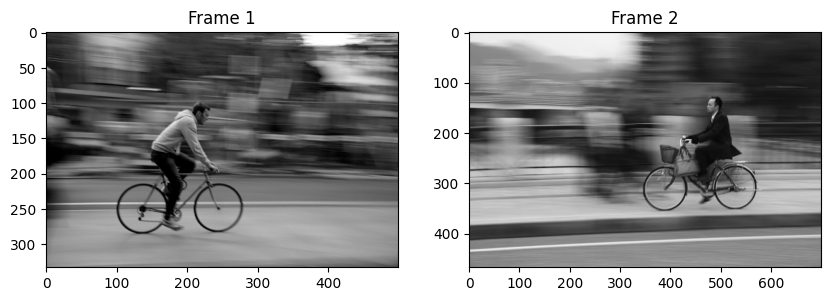

In [ ]:
# Load images in grayscale
img1 = cv2.imread("image1.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("image2.jpg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Frame 1")
plt.imshow(img1, cmap='gray')

plt.subplot(1,2,2)
plt.title("Frame 2")
plt.imshow(img2, cmap='gray')
plt.show()


In [ ]:
def compute_sad(block1, block2):
    return np.sum(np.abs(block1 - block2))


In [ ]:
def block_matching(img1, img2, block_size=16, search_range=8):
    h, w = img1.shape
    motion_vectors = []

    for y in range(0, h - block_size, block_size):
        for x in range(0, w - block_size, block_size):

            block = img1[y:y+block_size, x:x+block_size]
            min_sad = float('inf')
            best_dx, best_dy = 0, 0

            # Search window
            for dy in range(-search_range, search_range+1):
                for dx in range(-search_range, search_range+1):

                    new_x = x + dx
                    new_y = y + dy

                    if (0 <= new_x < w-block_size and
                        0 <= new_y < h-block_size):

                        candidate_block = img2[new_y:new_y+block_size,
                                               new_x:new_x+block_size]

                        sad = compute_sad(block, candidate_block)

                        if sad < min_sad:
                            min_sad = sad
                            best_dx = dx
                            best_dy = dy

            motion_vectors.append((x, y, best_dx, best_dy))

    return motion_vectors


In [ ]:
motion_vectors = block_matching(img1, img2,
                                block_size=16,
                                search_range=8)

print("Total motion vectors:", len(motion_vectors))


Total motion vectors: 620


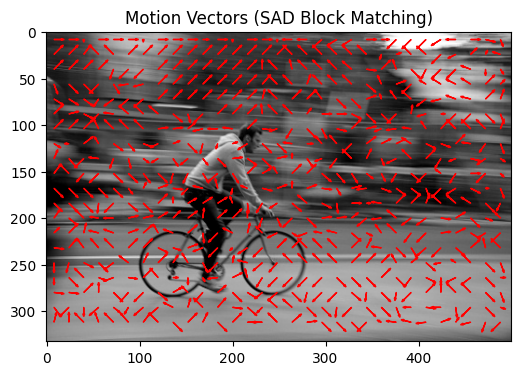

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(img1, cmap='gray')

for (x, y, dx, dy) in motion_vectors:
    plt.arrow(x+8, y+8, dx, dy,
              color='red', head_width=2)

plt.title("Motion Vectors (SAD Block Matching)")
plt.show()
